What you will create
You will create a logistic regression model that uses examination scores to predict university admission.
dataset available here



Your Task
Data Exploration: Load and visualize the data.

Use pandas to load the dataset and examine the first few rows.
Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores.
Applying Logistic Regression with scikit-learn:

Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.
Train the logistic regression model on your dataset.
Making Predictions:

Use the trained logistic regression model to make predictions on your dataset.
Calculate the accuracy of your model.
Model Evaluation:

Interpret the result of logistic regression and the accuracy of your model.


In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/kaleko/CourseraML/master/ex2/data/ex2data1.txt'

df = pd.read_csv(url, header=None, names=['exam1', 'exam2', 'admitted'])

df.head()

,exam1,exam2,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


## Task 1: Data Exploration

In [3]:
# Examine the dataset
print(df.shape)
print(df.dtypes)
df.describe()

(100, 3)
exam1       float64
exam2       float64
admitted      int64
dtype: object


,exam1,exam2,admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


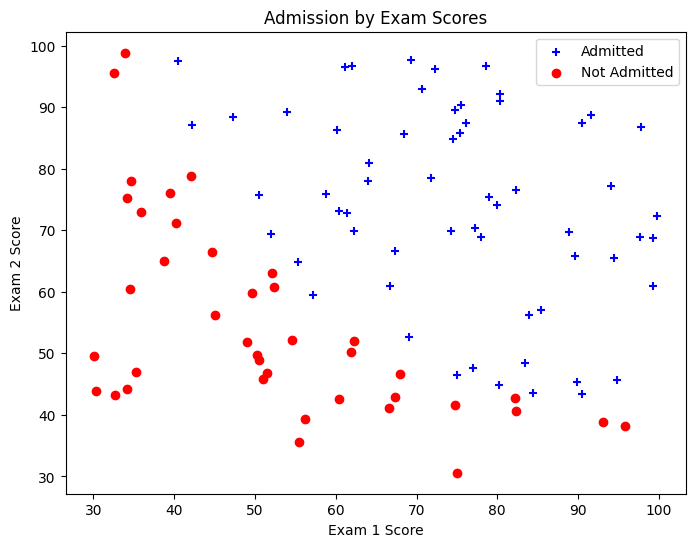

In [4]:
import matplotlib.pyplot as plt

admitted = df[df['admitted'] == 1]
not_admitted = df[df['admitted'] == 0]

plt.figure(figsize=(8, 6))
plt.scatter(admitted['exam1'], admitted['exam2'], marker='+', color='blue', label='Admitted')
plt.scatter(not_admitted['exam1'], not_admitted['exam2'], marker='o', color='red', label='Not Admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Admission by Exam Scores')
plt.legend()
plt.show()

## Task 2: Applying Logistic Regression with scikit-learn

In [5]:
from sklearn.linear_model import LogisticRegression

X = df[['exam1', 'exam2']]
y = df['admitted']

model = LogisticRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [-25.05219314]
Coefficients: [[0.20535491 0.2005838 ]]


## Task 3: Making Predictions

In [6]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)

print(f"Predictions: {y_pred}")
print(f"Accuracy: {accuracy:.2%}")

Predictions: [0 0 0 1 1 0 1 0 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0 1
 1 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 1 1 0 1 1 1
 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 0 1]
Accuracy: 89.00%


## Task 4: Model Evaluation

The logistic regression model achieves around **89% accuracy** on the training data, meaning it correctly classifies 89 out of 100 students.

**Interpreting the coefficients:**
- Both `exam1` and `exam2` have positive coefficients, meaning higher scores on either exam increase the probability of admission.
- The decision boundary is a straight line in the 2D exam score space — students above the line are predicted as admitted, those below are not.

**Limitations:**
- We evaluated on the same data used for training (no train/test split), so the accuracy is optimistic. A proper evaluation would use a held-out test set or cross-validation.
- The model assumes a linear decision boundary, which may not capture more complex patterns in the data.